In [1]:
# %%
# RAG Chunking + Embedding Evaluation — compact, DRY, Jupyter-first

import math
from pathlib import Path
import re
import subprocess
from textwrap import dedent

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

sns.set_context("talk")
sns.set_style("whitegrid")

print("✅ Imports & styling ready.")


✅ Imports & styling ready.


In [2]:
# %%
# --- Config (edit as needed) ---
CSV_PATH = "../artifacts/loss.csv"     # evaluator CSV path
OUT_DIR = Path("../artifacts/figs")    # output directory
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Defaults for metrics
K_DEFAULT = 10
BETA = 2.0    # weight recall in RRF@k
ALPHA = 2.0   # recall exponent for RRF-G
GAMMA = 1.0   # nDCG exponent for RRF-G
DELTA = 0.5   # MRR exponent for RRF-G

# Common plot tunables
HEATMAP_CMAP = "RdYlGn"
TOPN_CURVES = 5
CHUNK_SIZES = [128, 256, 384, 448]
OVERLAPS = [0, 16, 32, 64]

print(f"CSV_PATH = {CSV_PATH}")
print(f"OUT_DIR  = {OUT_DIR.resolve()}")


CSV_PATH = ../artifacts/loss.csv
OUT_DIR  = /home/chunk_twice_embed_once/artifacts/figs


In [3]:
# Full model name → Short name mapping
model_name_map = {
    "BAAI__bge-base-en": "BAAI_bgeB",
    "BAAI__bge-base-en-v1.5": "BAAI_bgeB_v1.5",
    "BAAI__bge-large-en": "BAAI_bgeL",
    "BAAI__bge-large-en-v1.5": "BAAI_bgeL_v1.5",
    "BAAI__bge-small-en": "BAAI_bgeS",
    "BAAI__bge-small-en-v1.5": "BAAI_bgeS_v1.5",
    "BAAI__bge-m3": "BAAI_bgeM3",
    "DeepChem__ChemBERTa-77M-MTR": "DC_ChemBERTa",
    "facebook__contriever": "FB_contriever",
    "facebook__contriever-msmarco": "FB_contrieverMS",
    "google-bert__bert-base-uncased": "GGL_BERTbU",
    "intfloat__e5-small": "Intf_e5S",
    "intfloat__e5-small-v2": "Intf_e5S_v2",
    "intfloat__e5-base": "Intf_e5B",
    "intfloat__e5-base-v2": "Intf_e5B_v2",
    "intfloat__e5-large": "Intf_e5L",
    "intfloat__e5-large-v2": "Intf_e5L_v2",
    "intfloat__multilingual-e5-base": "Intf_mE5B",
    "intfloat__multilingual-e5-large": "Intf_mE5L",
    "intfloat__multilingual-e5-small": "Intf_mE5S",
    "jinaai__jina-embeddings-v2-base-en": "Jina_v2B",
    "jinaai__jina-embeddings-v2-small-en": "Jina_v2S",
    "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext": "MS_BiomedBERT_af",
    "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext": "MS_PubMedBERT_af",
    "microsoft__MiniLM-L12-H384-uncased": "MS_MiniLM384",
    "microsoft__mpnet-base": "MS_MPNetB",
    "m3rg-iitd__matscibert": "IITD_MatSci",
    "nomic-ai__nomic-bert-2048": "Nomic_BERT2048",
    "nomic-ai__nomic-embed-text-v1": "Nomic_text_v1",
    "nomic-ai__nomic-embed-text-v1.5": "Nomic_text_v1.5",
    "nomic-ai__nomic-embed-text-v2-moe":"Nomic_text_v2",
    "describeai__gemini": "Desc_Gemini",
    "hkunlp__instructor-xl": "HKU_InstructXL",
    "allenai__scibert_scivocab_uncased": "AI_SciBERT",
    "allenai__specter": "AI_Specter",
    "recobo__chemical-bert-uncased": "Rec_ChemBERT",
    "sentence-transformers__all-mpnet-base-v2": "Sent_allMPNetB_v2",
    "sentence-transformers__all-MiniLM-L6-v2": "Sent_MiniLM6_v2",
    "sentence-transformers__all-MiniLM-L12-v2": "Sent_MiniLM12_v2",
    "sentence-transformers__bert-base-nli-mean-tokens": "Sent_BERTnli",
    "sentence-transformers__gtr-t5-base": "Sent_gtrT5_B",
    "sentence-transformers__gtr-t5-large": "Sent_gtrT5_L",
    "sentence-transformers__gtr-t5-xl": "Sent_gtrT5_XL",
    "sentence-transformers__multi-qa-mpnet-base-dot-v1": "Sent_MQA_MPNetB",
    "sentence-transformers__paraphrase-multilingual-MiniLM-L12-v2": "Sent_paraMiniLM12",
    "multi-qa-mpnet-base-dot-v1": "MQA_MPNetB",
    "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract" : "MS_PubMedBERT_a",
    "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract" : "MS_BiomedBERT_a",
    "sentence-transformers__paraphrase-multilingual-mpnet-base-v2" : "Sent_paraMPNetB_v2",
}


In [4]:
# %%
# ---------- Utilities: IO / columns / metrics / labels / saving ----------

def _safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def harmonize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename = {}
    at_k_regex = re.compile(r'^(?P<base>[A-Za-z\-]+)@(?P<k>\d+|k)$')

    for c in list(df.columns):
        cs = c.strip()
        m = at_k_regex.match(cs)
        if not m:
            continue
        base = m.group("base").lower()
        kval = m.group("k")

        def mk(base_name: str) -> str:
            return f"{base_name}_at_k" if kval == "k" else f"{base_name}_at_{kval}"

        if base in ("ndcg", "recall", "map", "mrr"):
            new_c = mk(base)
        elif base in ("precision", "p"):
            new_c = mk("precision")
        elif base in ("rrf", "rrf-beta", "rrfβ"):
            new_c = "rrf_beta_at_k"
        elif base in ("rrf-g", "rrfg", "rrf_g"):
            new_c = "rrf_g_at_k"
        else:
            continue

        rename[c] = new_c

    df = df.rename(columns=rename)

    # determine k for *_at_k → *_at_<k>
    k_series = next((df[col] for col in ("k_req", "k_request") if col in df.columns), None)
    k_used = int(_safe_num(k_series.dropna().iloc[0])) if k_series is not None and pd.notna(k_series).any() else K_DEFAULT

    for base in ("ndcg", "recall", "map", "mrr", "precision"):
        generic = f"{base}_at_k"
        specific = f"{base}_at_{k_used}"
        if generic in df.columns and specific not in df.columns:
            df[specific] = _safe_num(df[generic])

    if 'model_short' not in df.columns and 'model_name' in df.columns:
        df['model_short'] = df['model_name'].astype(str).str.replace(r'[_\-]+', ' ', regex=True)

    for c in ('token_size','overlap','cost_norm'):
        if c in df.columns:
            df[c] = _safe_num(df[c])
    if 'cost_norm' not in df.columns:
        df['cost_norm'] = 1.0

    # drop duplicate column names if any
    if pd.Series(df.columns).duplicated().any():
        df = df.loc[:, ~pd.Series(df.columns).duplicated()].copy()

    return df

_K_REGEX = re.compile(r"^(?P<base>ndcg|recall|map|mrr)_at_(?P<k>\d+)$")

def _nearest_k_available(df: pd.DataFrame, base: str, k: int):
    cands = [(c, int(m.group("k"))) for c in df.columns if (m := _K_REGEX.match(c)) and m.group("base")==base]
    if not cands:
        return (None, None)
    return min(cands, key=lambda t: abs(t[1]-k))

def _get_metric_series(df: pd.DataFrame, base: str, k: int):
    exact = f"{base}_at_{k}"
    if exact in df.columns:
        return (_safe_num(df[exact]), k, exact, None)
    col, used_k = _nearest_k_available(df, base, k)
    if col is None:
        return (pd.Series([np.nan]*len(df), index=df.index), None, None,
                f"Missing {base}@{k} and no {base}_at_* columns found.")
    warn = None if used_k==k else f"Missing {base}_at_{k}; using {base}_at_{used_k} instead."
    return (_safe_num(df[col]), used_k, col, warn)

def rrf_beta(recall, ndcg, beta=BETA):
    r = np.clip(_safe_num(recall).to_numpy(), 0, None)
    n = np.clip(_safe_num(ndcg).to_numpy(), 0, None)
    b2 = float(beta)**2
    num = (1 + b2) * r * n
    den = (b2 * n + r)
    out = np.divide(num, den, out=np.zeros_like(num), where=(den>0) & (r>0) & (n>0))
    return pd.Series(out)

def rrf_g(recall, ndcg, mrr=None, alpha=ALPHA, gamma=GAMMA, delta=DELTA):
    r = np.clip(_safe_num(recall).to_numpy(), 0, None)
    n = np.clip(_safe_num(ndcg).to_numpy(), 0, None)
    mask_req = (r>0) & (n>0)
    out = np.zeros_like(r, dtype=float)
    if mrr is None:
        prod = (np.power(r, alpha) * np.power(n, gamma))
        power = 1.0 / (alpha + gamma)
        with np.errstate(invalid='ignore'):
            out[mask_req] = np.power(prod[mask_req], power)
    else:
        m = np.clip(_safe_num(mrr).to_numpy(), 0, None)
        mask = mask_req & (m>0)
        prod = (np.power(r, alpha) * np.power(n, gamma) * np.power(m, delta))
        power = 1.0 / (alpha + gamma + delta)
        with np.errstate(invalid='ignore'):
            out[mask] = np.power(prod[mask], power)
    return pd.Series(out)

def ensure_cols(df: pd.DataFrame, k=K_DEFAULT, beta=BETA, alpha=ALPHA, gamma=GAMMA, delta=DELTA):
    df = df.copy()

    # Keep/ensure conveniences
    if 'chunker' in df.columns:
        df['chunker'] = df['chunker'].fillna('unknown')
    if 'model_name' in df.columns and 'model_short' not in df.columns:
        df['model_short'] = df['model_name'].astype(str).str.replace(r'[_\-]+', ' ', regex=True)
    for c in ['token_size','overlap']:
        if c in df: df[c] = _safe_num(df[c])
    if 'cost_norm' not in df.columns:
        df['cost_norm'] = 1.0

    warns = []
    rec_s, k_rec, _, w = _get_metric_series(df, "recall", k);  warns += [w] if w else []
    ndc_s, k_ndc, _, w = _get_metric_series(df, "ndcg",   k);  warns += [w] if w else []
    map_s, k_map, _, w = _get_metric_series(df, "map",    k);  warns += [w] if w else []
    mrr_s, k_mrr, _, w = _get_metric_series(df, "mrr",    k);  warns += [w] if w else []

    df['recall_at_k'] = rec_s
    df['ndcg_at_k']   = ndc_s
    df['map_at_k']    = map_s
    df['mrr_at_k']    = mrr_s

    if 'rrf_beta_at_k' not in df:
        df['rrf_beta_at_k'] = rrf_beta(df['recall_at_k'], df['ndcg_at_k'], beta=beta)
    if 'rrf_g_at_k' not in df:
        df['rrf_g_at_k']    = rrf_g(df['recall_at_k'], df['ndcg_at_k'], df['mrr_at_k'],
                                    alpha=alpha, gamma=gamma, delta=delta)

    df['k_request']     = k
    df['k_recall_used'] = k_rec
    df['k_ndcg_used']   = k_ndc
    df['k_map_used']    = k_map
    df['k_mrr_used']    = k_mrr
    df['beta']          = beta
    df['alpha']         = alpha
    df['gamma']         = gamma
    df['delta']         = delta

    for msg in sorted(set([m for m in warns if m])):
        print("⚠️", msg)
    return df

def pick_metric(df: pd.DataFrame, prefs=("rrf_beta_at_k", "rrf_g_at_k", "ndcg_at_k")):
    for m in prefs:
        if m in df.columns: return m
    raise ValueError(f"No metric columns found among {prefs}. Run ensure_cols() first.")

PRETTY = {
    "rrf_beta_at_k": "RRF@k",
    "rrf_g_at_k":    "RRF-G@k",
    "ndcg_at_k":     "nDCG@k",
}

def metric_title(df, metric_col):
    parts = [PRETTY.get(metric_col, metric_col)]
    if "k_request" in df and df["k_request"].notna().any():
        parts.append(f"k={int(df['k_request'].dropna().iloc[0])}")
    if metric_col=="rrf_beta_at_k" and "beta" in df and df["beta"].notna().any():
        try:
            parts.append(f"β={df['beta'].dropna().iloc[0]:g}")
        except Exception:
            parts.append(f"β={df['beta'].dropna().iloc[0]}")
    return " • ".join(parts)

def savefig(fig, name_base: str):
    png = OUT_DIR / f"{name_base}.png"
    pdf = OUT_DIR / f"{name_base}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {png.name} | {pdf.name}")

def pareto_frontier(df, x='cost_norm', y='rrf_beta_at_k', minimize_x=True, maximize_y=True):
    X = df[x].to_numpy()
    Y = df[y].to_numpy()
    order = np.lexsort((-Y, X)) if (minimize_x and maximize_y) else np.argsort(X)
    best_y = -math.inf
    mask = np.zeros(len(df), dtype=bool)
    for idx in order:
        yi = Y[idx]
        if yi > best_y + 1e-12:
            mask[idx] = True
            best_y = yi
    return mask

def latex_table(df, caption, label, floatfmt="{:.3f}", bold_cols=()):
    df2 = df.copy()
    for col in bold_cols:
        if col in df2:
            if df2[col].dtype.kind in "fiu":
                best = df2[col].max()
            else:
                best = None
            def fmt_bold(v):
                s = floatfmt.format(v) if isinstance(v, (float,int,np.floating,np.integer)) else str(v)
                return r"\textbf{" + s + "}" if best is not None and v == best else s
            df2[col] = df2[col].apply(fmt_bold)

    for col in df2.columns:
        if col in bold_cols: continue
        if pd.api.types.is_numeric_dtype(df2[col]):
            df2[col] = df2[col].apply(lambda v: floatfmt.format(v))

    header = " & ".join(df2.columns) + r" \\"
    rows = [" & ".join(map(str, r)) + r" \\" for r in df2.itertuples(index=False, name=None)]
    colspec = " ".join(["l"] * len(df2.columns))
    return (
        "\\begin{table}[t]\n\\centering\n\\small\n"
        f"\\begin{tabular}{{{colspec}}}\n\\toprule\n"
        f"{header}\n\\midrule\n" + "\n".join(rows) +
        "\n\\bottomrule\n\\end{tabular}\n"
        f"\\caption{{{caption}}}\n\\label{{{label}}}\n\\end{table}"
    )

MODEL_OVERRIDES = {
    "BAAI bge base en v1.5": "bge-base-1.5",
    "BAAI bge large en v1.5": "bge-large-1.5",
    "intfloat e5 base": "e5-base",
    "intfloat e5 small": "e5-small",
    "intfloat e5 large": "e5-large",
    "intfloat multilingual e5 base": "e5-multi-base",
    "nomic ai nomic embed text v1.5": "nomic-txt-1.5",
    "nomic ai nomic embed text v1": "nomic-txt-1.0",
}
CHUNKER_OVERRIDES = {
    "fixed_token": "fixed",
    "hierarchical_section": "hier-sect",
    "recursive_token": "recur",
    "semantic_fixed": "sem-fixed",
    "semantic_recursive": "sem-recur",
}

def make_unique(labels):
    seen, out = {}, []
    for x in labels:
        n = seen.get(x, 0) + 1
        seen[x] = n
        out.append(x if n == 1 else f"{x}-{n}")
    return out


In [5]:
# %%
# ---------- Load data, harmonize & compute composite metrics ----------

df = pd.read_csv(CSV_PATH)
print("✅ CSV loaded.")
display(df.head(10))
print("\nColumns:", list(df.columns))
print("Shape:", df.shape)

_before = set(df.columns)
df = harmonize_columns(df)
df = ensure_cols(df, k=K_DEFAULT, beta=BETA, alpha=ALPHA, gamma=GAMMA, delta=DELTA)
_added = sorted(list(set(df.columns) - _before))
print("\n✅ Harmonized + ensure_cols complete. New columns:", _added or "(none)")
display(df.head(5)[_added] if _added else df.head(5))


✅ CSV loaded.


,model_name,chunker,token_size,overlap,RRF@k,RRF-G@k,Recall@k,nDCG@k,MRR@k,MAP@k,k_req,k_recall_used,k_ndcg_used,k_mrr_used,k_map_used,beta,alpha,gamma,delta,rel_path
0,intfloat_e5_base,fixed_token,512,0,0.6479,0.5826,0.6875,0.4761,0.4497,0.3838,10,10,10,10,10,2.5,2.0,1.0,0.5,intfloat_e5_base_fixed_token_c512_o0/results/i...
1,intfloat_e5_base,recursive_token,512,0,0.6416,0.5760,0.6806,0.4722,0.4394,0.3839,10,10,10,10,10,2.5,2.0,1.0,0.5,intfloat_e5_base_recursive_token_c512_o0/resul...
2,BAAI_bge_m3,semantic_fixed,512,0,0.6378,0.5751,0.6750,0.4742,0.4456,0.3863,10,10,10,10,10,2.5,2.0,1.0,0.5,BAAI_bge_m3_semantic_fixed_c512_o0/results/BAA...
3,nomic_ai_nomic_embed_text_v1,recursive_token,512,0,0.6375,0.5694,0.6789,0.4617,0.4285,0.3705,10,10,10,10,10,2.5,2.0,1.0,0.5,nomic_ai_nomic_embed_text_v1_recursive_token_c...
4,BAAI_bge_m3,fixed_token,512,0,0.6345,0.5737,0.6712,0.4729,0.4505,0.3843,10,10,10,10,10,2.5,2.0,1.0,0.5,BAAI_bge_m3_fixed_token_c512_o0/results/BAAI__...
5,intfloat_e5_large,recursive_token,512,0,0.6320,0.5712,0.6677,0.4737,0.4449,0.3910,10,10,10,10,10,2.5,2.0,1.0,0.5,intfloat_e5_large_recursive_token_c512_o0/resu...
6,BAAI_bge_m3,recursive_token,512,0,0.6311,0.5661,0.6705,0.4617,0.4324,0.3719,10,10,10,10,10,2.5,2.0,1.0,0.5,BAAI_bge_m3_recursive_token_c512_o0/results/BA...
7,intfloat_e5_base,fixed_token,448,0,0.6277,0.5623,0.6672,0.4583,0.4271,0.3691,10,10,10,10,10,2.5,2.0,1.0,0.5,intfloat_e5_base_fixed_token_c448_o0/results/i...
8,intfloat_e5_large,fixed_token,512,0,0.6270,0.5676,0.6629,0.4684,0.4482,0.3811,10,10,10,10,10,2.5,2.0,1.0,0.5,intfloat_e5_large_fixed_token_c512_o0/results/...
9,BAAI_bge_m3,recursive_token,448,0,0.6263,0.5699,0.6597,0.4755,0.4558,0.3916,10,10,10,10,10,2.5,2.0,1.0,0.5,BAAI_bge_m3_recursive_token_c448_o0/results/BA...



Columns: ['model_name', 'chunker', 'token_size', 'overlap', 'RRF@k', 'RRF-G@k', 'Recall@k', 'nDCG@k', 'MRR@k', 'MAP@k', 'k_req', 'k_recall_used', 'k_ndcg_used', 'k_mrr_used', 'k_map_used', 'beta', 'alpha', 'gamma', 'delta', 'rel_path']
Shape: (1820, 20)

✅ Harmonized + ensure_cols complete. New columns: ['cost_norm', 'k_request', 'map_at_10', 'map_at_k', 'model_short', 'mrr_at_10', 'mrr_at_k', 'ndcg_at_10', 'ndcg_at_k', 'recall_at_10', 'recall_at_k', 'rrf_beta_at_k', 'rrf_g_at_k']


,cost_norm,k_request,map_at_10,map_at_k,model_short,mrr_at_10,mrr_at_k,ndcg_at_10,ndcg_at_k,recall_at_10,recall_at_k,rrf_beta_at_k,rrf_g_at_k
0,1.0,10,0.3838,0.3838,intfloat e5 base,0.4497,0.4497,0.4761,0.4761,0.6875,0.6875,0.6479,0.5826
1,1.0,10,0.3839,0.3839,intfloat e5 base,0.4394,0.4394,0.4722,0.4722,0.6806,0.6806,0.6416,0.5760
2,1.0,10,0.3863,0.3863,BAAI bge m3,0.4456,0.4456,0.4742,0.4742,0.6750,0.6750,0.6378,0.5751
3,1.0,10,0.3705,0.3705,nomic ai nomic embed text v1,0.4285,0.4285,0.4617,0.4617,0.6789,0.6789,0.6375,0.5694
4,1.0,10,0.3843,0.3843,BAAI bge m3,0.4505,0.4505,0.4729,0.4729,0.6712,0.6712,0.6345,0.5737


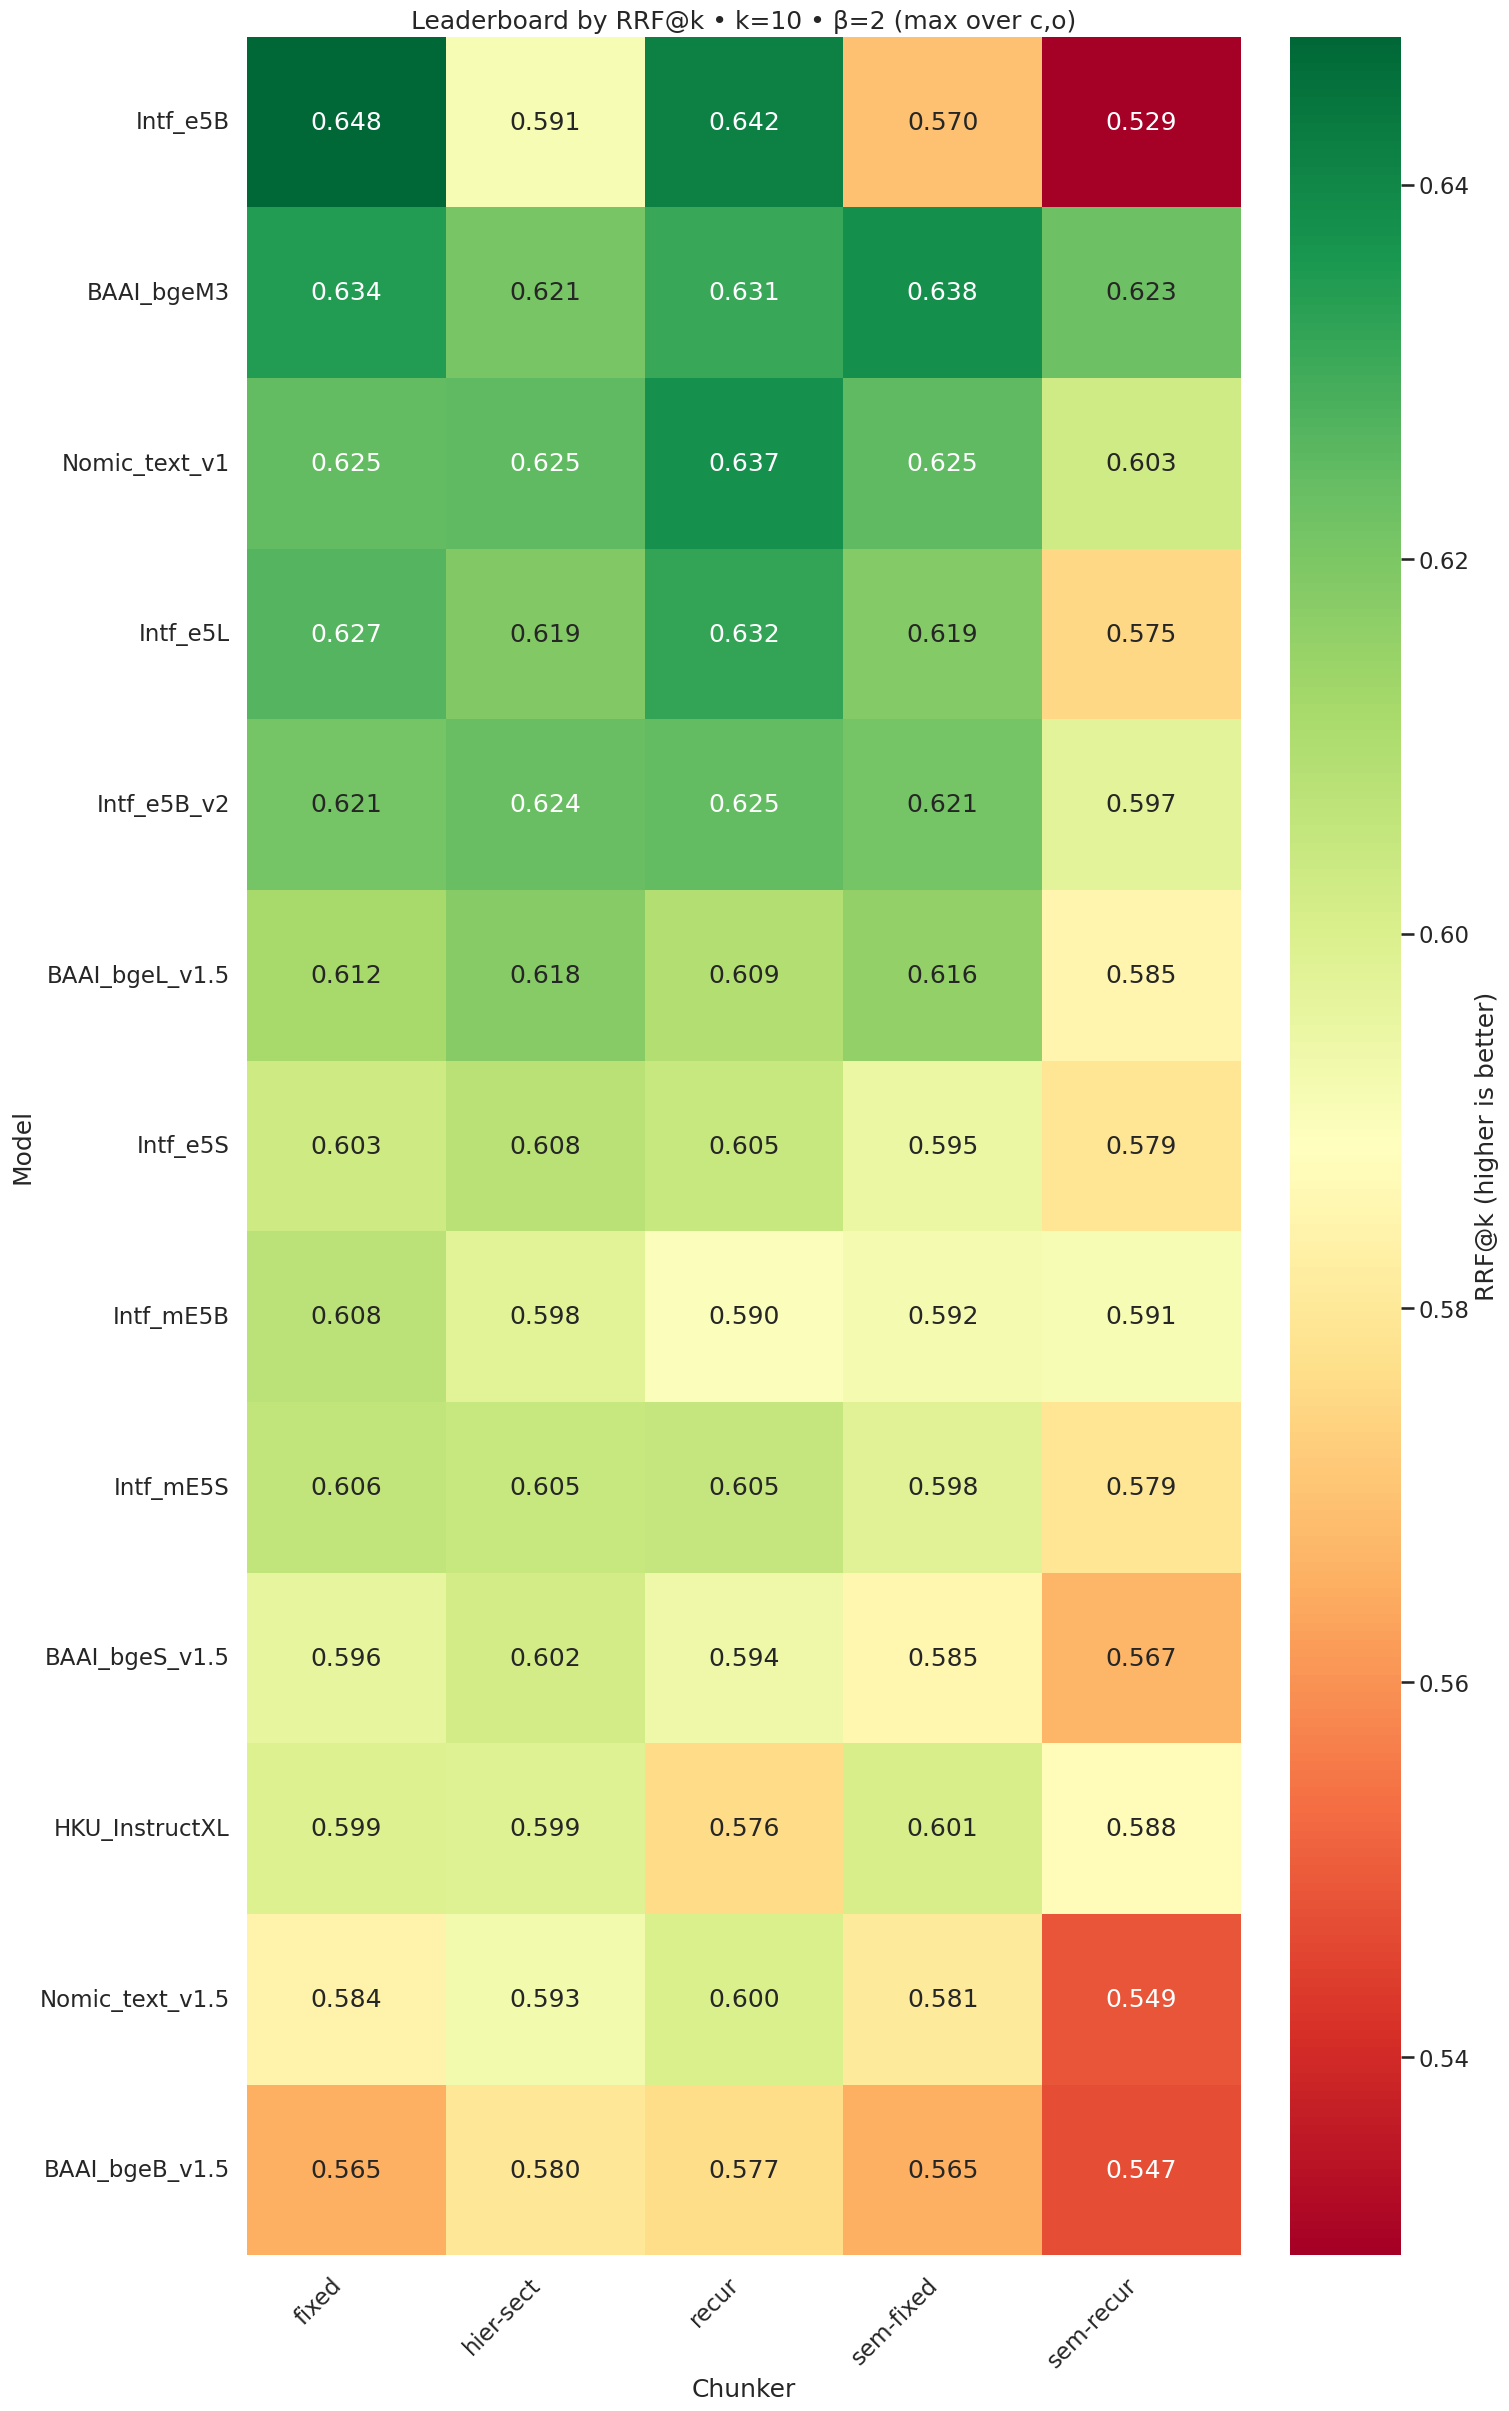

✅ Saved: fig_leaderboard_heatmap_rrf_beta_at_k.png | fig_leaderboard_heatmap_rrf_beta_at_k.pdf


In [8]:
# %%
# ---------- Leaderboard heatmap (max over c,o per model×chunker) ----------

import re
import numpy as np

metric_col = pick_metric(df)
df[metric_col] = _safe_num(df[metric_col])

# ensure required cols
if 'chunker' not in df.columns:
    df['chunker'] = 'unknown'
df['chunker'] = df['chunker'].fillna('unknown')
if 'model_short' not in df.columns and 'model_name' in df.columns:
    df['model_short'] = df['model_name'].astype(str).str.replace(r'[_\-]+', ' ', regex=True)

# --- Use provided short names for models (robust mapping; prefers your map) ---
def _norm_model_repo(x: str) -> str:
    # org/repo[@rev] → org__repo
    base = str(x).split("@", 1)[0].strip()
    return base.replace("/", "__")

def _norm_model_pretty(x: str) -> str:
    # lower-case and collapse / _ - to single spaces
    s = str(x).lower().strip()
    s = re.sub(r"[/_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

# build secondary mapping for pretty-style keys (e.g., "intfloat e5 base")
_model_pretty_map = { _norm_model_pretty(k): v for k, v in model_name_map.items() }

_src_col = next((c for c in ("model_name", "model", "name") if c in df.columns), None)
if _src_col is not None:
    repo_key   = df[_src_col].apply(_norm_model_repo).map(model_name_map)
    pretty_key = df[_src_col].apply(_norm_model_pretty).map(_model_pretty_map)
    mapped = repo_key.fillna(pretty_key)
    df["model_short"] = mapped.fillna(df.get("model_short", df[_src_col]))

# aggregate best score per (model, chunker) over size/overlap
agg = (df.groupby(["model_short", "chunker"], as_index=False)[metric_col]
         .max())

pivot = pd.pivot_table(
    agg, index="model_short", columns="chunker", values=metric_col, aggfunc="max"
)

if pivot.size == 0:
    print("No data for heatmap.")
else:
    # order rows by each model's best score across chunkers
    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

    # apply only chunker overrides; KEEP your model_short labels as-is
    full_models, full_chunkers = list(pivot.index), list(pivot.columns)
    model_abbrs = make_unique(full_models)  # do not remap with MODEL_OVERRIDES
    chunk_abbrs = make_unique([CHUNKER_OVERRIDES.get(c, c) for c in full_chunkers])
    model_map = dict(zip(full_models, model_abbrs))
    chunk_map = dict(zip(full_chunkers, chunk_abbrs))

    pivot_disp = pivot.copy()
    pivot_disp.index = [model_map[m] for m in pivot.index]
    pivot_disp.columns = [chunk_map[c] for c in pivot.columns]

    # derive color scale from actual min/max (ignore NaNs)
    vmin = np.nanmin(pivot_disp.to_numpy(dtype=float))
    vmax = np.nanmax(pivot_disp.to_numpy(dtype=float))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        vmin, vmax = 0.0, 1.0
    elif abs(vmax - vmin) < 1e-9:
        eps = 1e-6
        vmin, vmax = vmin - eps, vmax + eps

    fig, ax = plt.subplots(figsize=(15, 24), constrained_layout=True)
    sns.heatmap(
        pivot_disp, annot=True, fmt=".3f",
        cmap=HEATMAP_CMAP, vmin=vmin, vmax=vmax,
        ax=ax, cbar_kws={"label": f"{PRETTY.get(metric_col, metric_col)} (higher is better)"},
        mask=pivot_disp.isna()
    )
    ax.set_title(f"Leaderboard by {metric_title(df, metric_col)} (max over c,o)")
    ax.set_xlabel("Chunker")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.show()
    savefig(fig, f"fig_leaderboard_heatmap_{metric_col}")
    plt.close(fig)


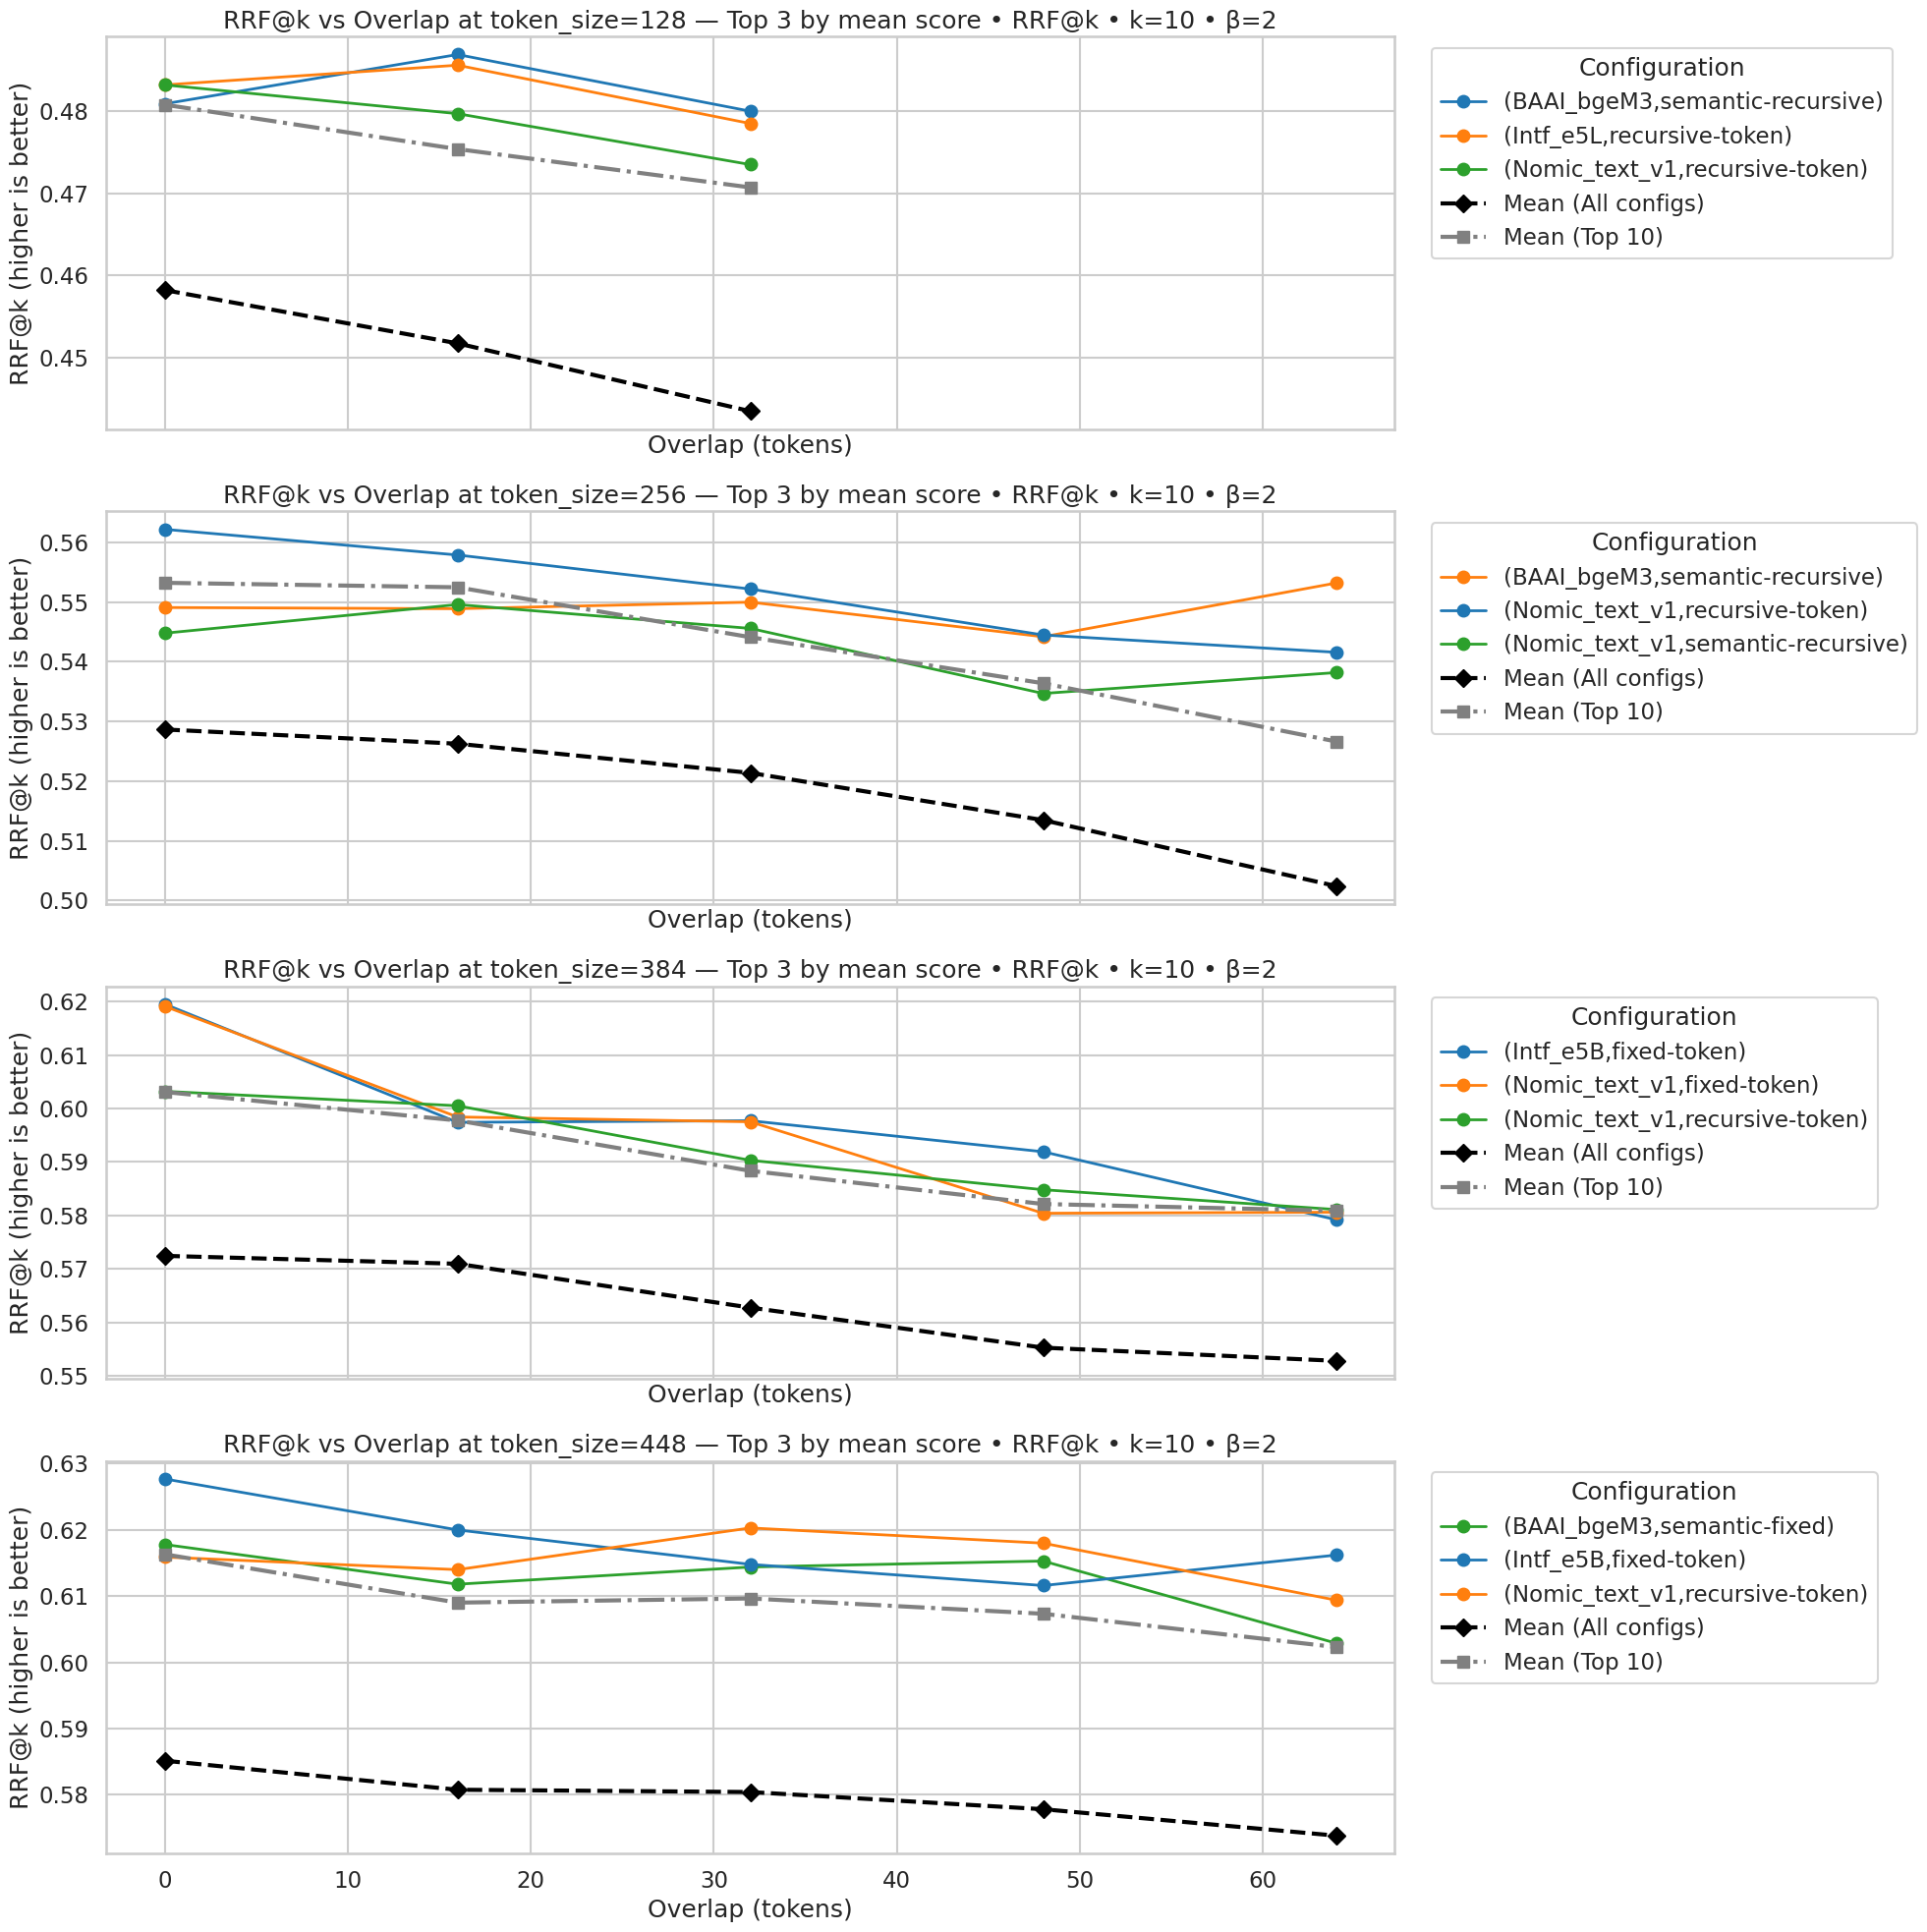

✅ Saved: fig_best_auc_overlap_rows_rrf_beta_at_k.png | fig_best_auc_overlap_rows_rrf_beta_at_k.pdf
✅ Saved combined leaderboard CSV (overlap).


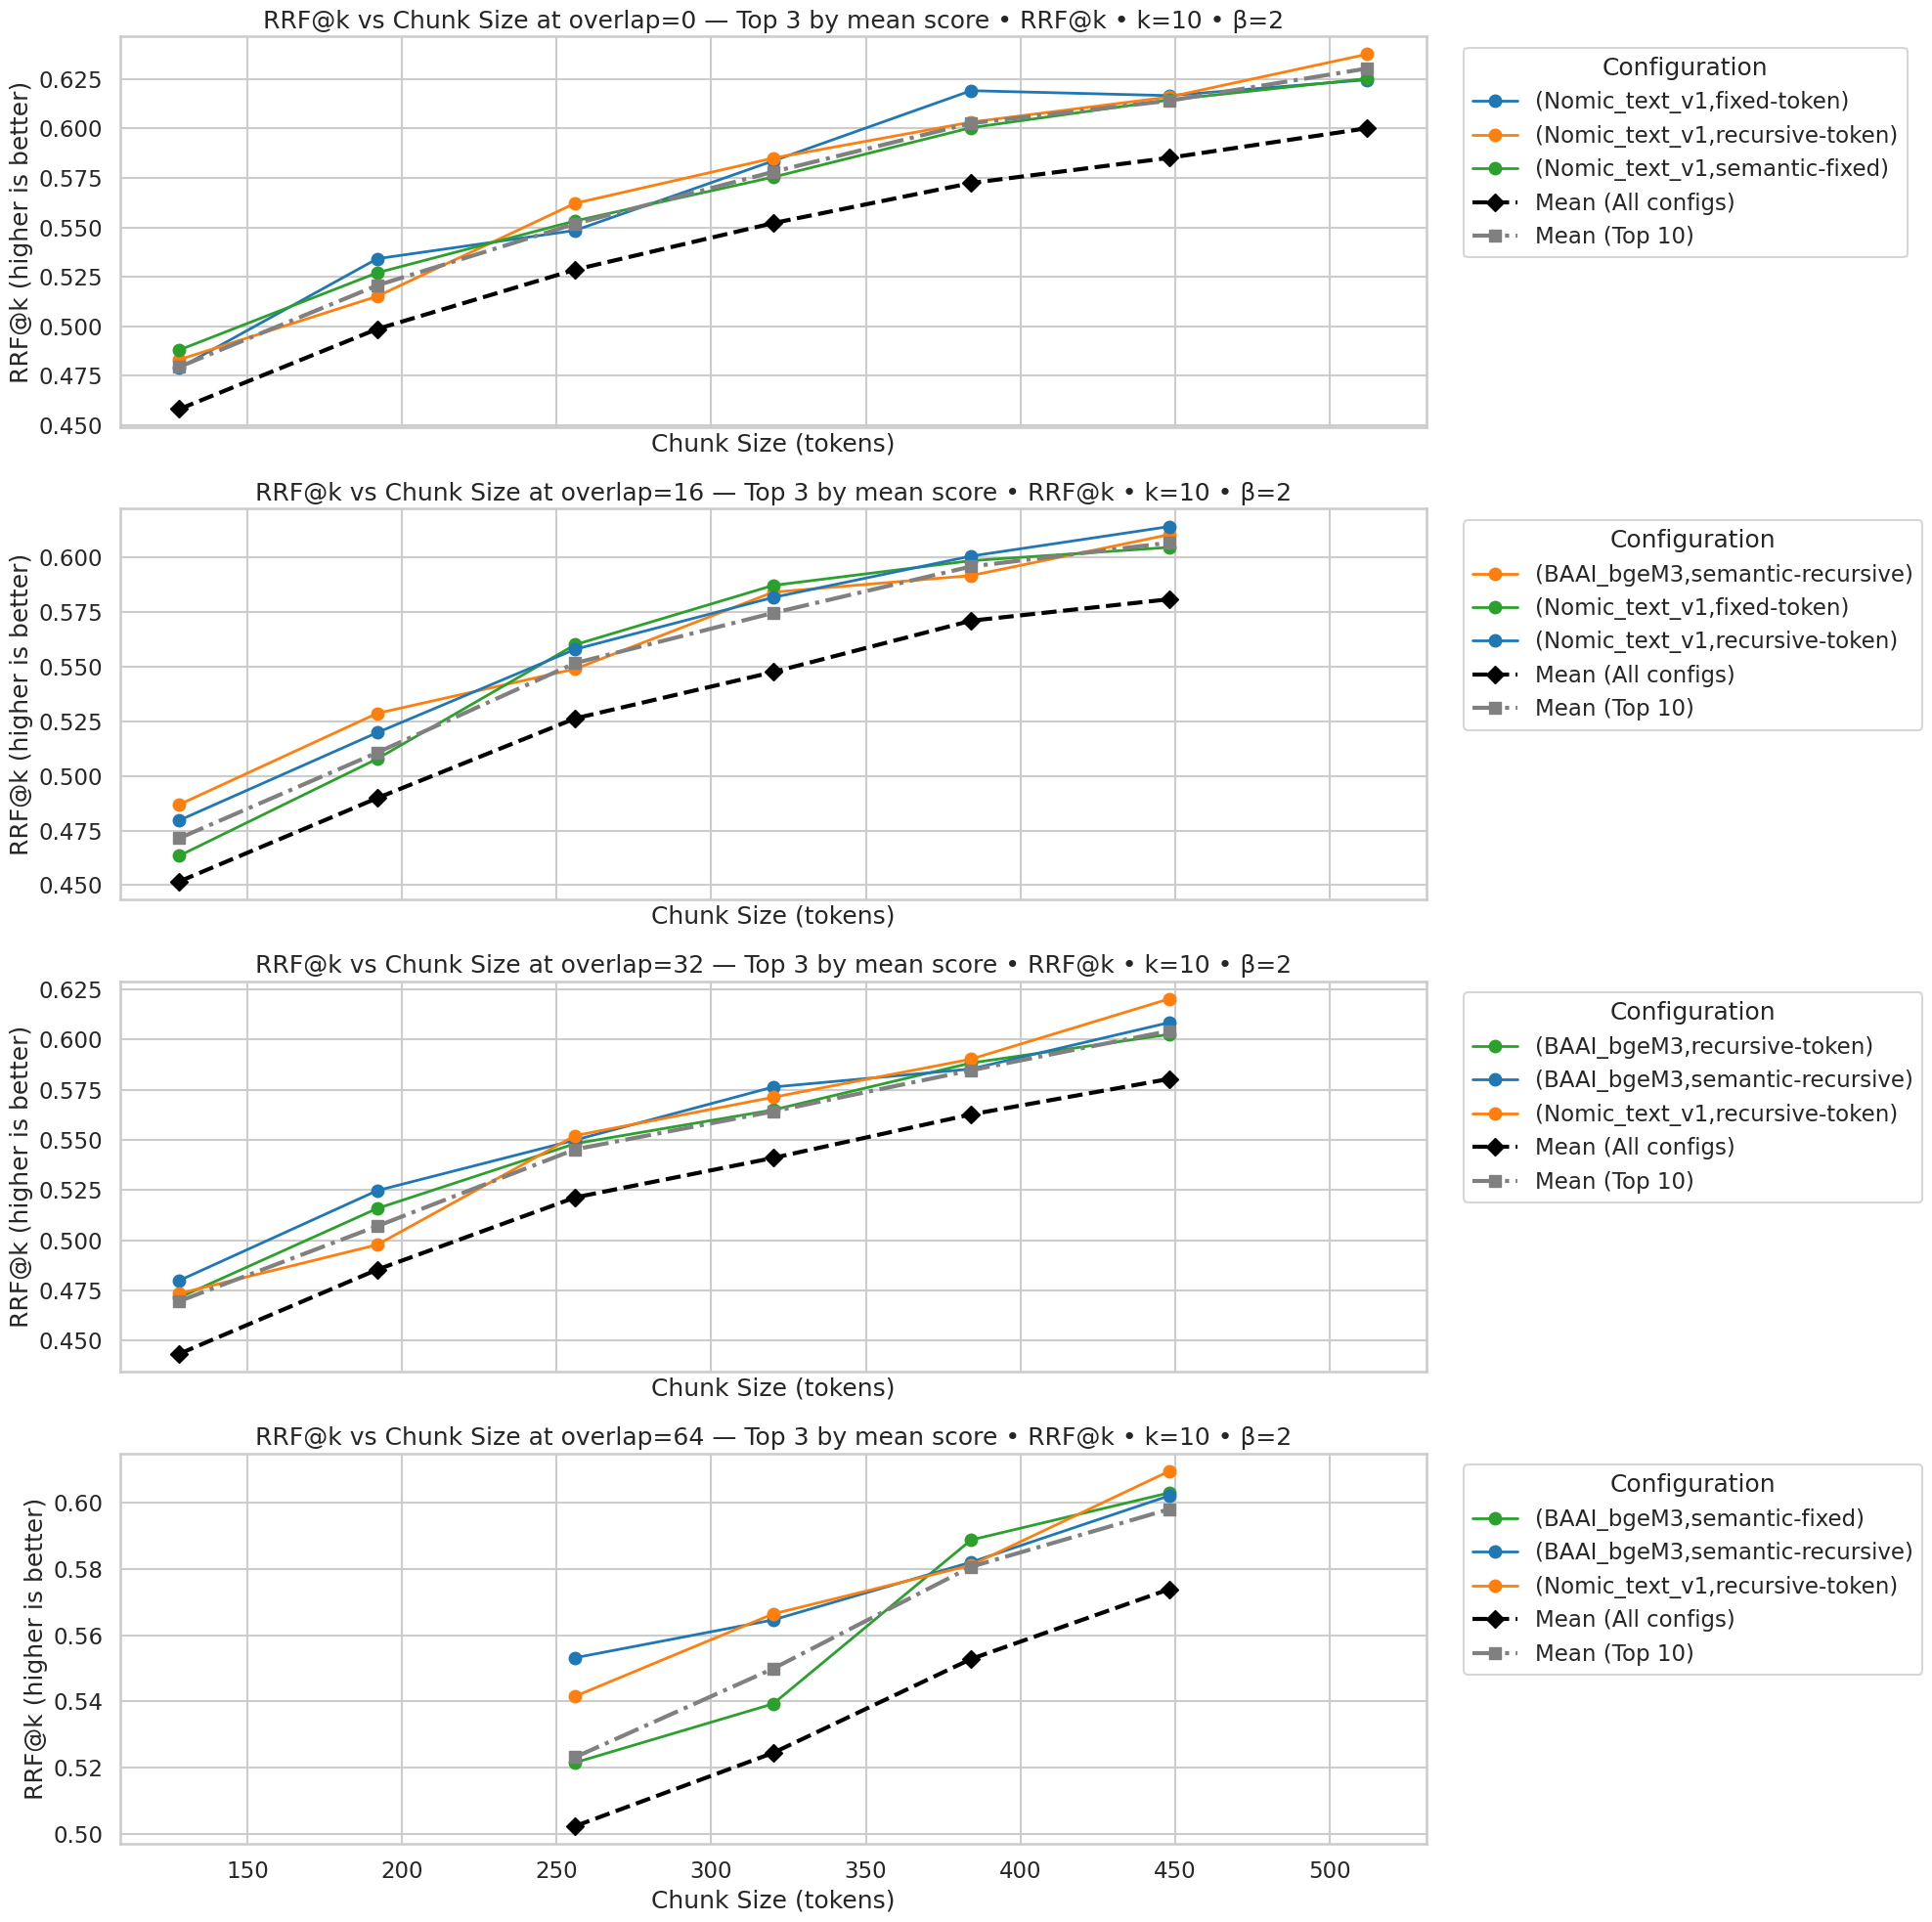

✅ Saved: fig_best_auc_chunksize_rows_rrf_beta_at_k.png | fig_best_auc_chunksize_rows_rrf_beta_at_k.pdf
✅ Saved combined leaderboard CSV (chunk size).


In [9]:
# %%
# ---------- Generic AUC plotter (overlap vs metric @ fixed c, and chunk size vs metric @ fixed o) ----------

_SUPERS = ['', '¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
def _sup(n: int) -> str:
    if n<=0: return ''
    return _SUPERS[n] if n < len(_SUPERS) else f'^{n+1}'

def plot_auc_vs_param(df, fixed_col, fixed_values, x_col, metric_col, topn=TOPN_CURVES, title_left="", x_label=""):
    figs = []
    leaderboards = []

    fig, axes = plt.subplots(len(fixed_values), 1, figsize=(20, 20), sharex=True)
    if len(fixed_values) == 1: axes = [axes]

    # --- minimal: helpers to normalize model ids for mapping (reuse if already defined) ---
    if 'model_name_map' in globals():
        try:
            _ = model_name_map
            # define only if missing
            if '_norm_model_repo' not in globals():
                def _norm_model_repo(x: str) -> str:
                    base = str(x).split("@", 1)[0].strip()
                    return base.replace("/", "__")
            if '_norm_model_pretty' not in globals():
                def _norm_model_pretty(x: str) -> str:
                    s = str(x).lower().strip()
                    s = re.sub(r"[/_\-]+", " ", s)
                    s = re.sub(r"\s+", " ", s)
                    return s
            _model_pretty_map = { _norm_model_pretty(k): v for k, v in model_name_map.items() }
        except Exception:
            _model_pretty_map = {}
    else:
        _model_pretty_map = {}

    for i, fixed_value in enumerate(fixed_values):
        ax = axes[i]
        sub = df[df.get(fixed_col, np.nan) == fixed_value].copy()
        if sub.empty:
            ax.set_title(f"{fixed_col}={fixed_value} (no data)")
            ax.set_xlabel(x_label)
            ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
            continue

        # ensure short names, then map to your abbreviations (minimal addition)
        if 'model_short' not in sub.columns:
            sub['model_short'] = sub.get('model_name', 'model')
        # map to abbreviations if we have a map
        if _model_pretty_map:
            src_col = 'model_name' if 'model_name' in sub.columns else 'model_short'
            repo_key   = sub[src_col].apply(_norm_model_repo).map(model_name_map)
            pretty_key = sub[src_col].apply(_norm_model_pretty).map(_model_pretty_map)
            mapped = repo_key.fillna(pretty_key)
            sub['model_short'] = mapped.fillna(sub['model_short'])

        cols_needed = ['model_short','chunker', x_col, metric_col]
        sub = (sub[cols_needed]
                 .dropna()
                 .assign(**{x_col: _safe_num(sub[x_col]), metric_col: _safe_num(sub[metric_col])})
                 .dropna())
        sub = (sub.sort_values(['model_short','chunker', x_col, metric_col])
                  .groupby(['model_short','chunker', x_col], as_index=False)
                  .first())

        mean_curve_all = (sub.groupby(x_col, as_index=False)[metric_col]
                        .mean()
                        .sort_values(x_col))
        # AUC (normalized by span) per (model, chunker)
        rows = []
        for (m, ck), g in sub.groupby(['model_short','chunker']):
            g = g.sort_values(x_col)
            x, y = g[x_col].to_numpy(), g[metric_col].to_numpy()
            if len(x) < 2: continue
            span = float(x.max() - x.min())
            if span <= 0: continue
            auc = np.trapz(y, x)
            rows.append({'fixed': fixed_value, 'model_short': m, 'chunker': ck,
                         'auc': auc, 'norm_auc': auc/span, 'n_points': len(x)})
        auc_df = pd.DataFrame(rows).sort_values('norm_auc', ascending=False)
        if auc_df.empty:
            ax.set_title(f"{fixed_col}={fixed_value} (no AUC computed)")
            ax.set_xlabel(x_label); ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
            continue

        top10 = auc_df.head(min(10, len(auc_df)))[['model_short','chunker']]
        sub_top10 = sub.merge(top10, on=['model_short','chunker'], how='inner')
        mean_curve_top10 = (sub_top10.groupby(x_col, as_index=False)[metric_col]
                              .mean()
                              .sort_values(x_col))

        winners = auc_df.head(min(topn, len(auc_df))).copy()
        leaderboards.append(winners)

        # keep only winners' curves
        keep = set(zip(winners['model_short'], winners['chunker']))
        plot_df = sub[sub.set_index(['model_short','chunker']).index.isin(keep)].copy()

        # model-only labels with superscripts for duplicates
        winners['occ'] = winners.groupby('model_short').cumcount()
        # winners['legend_label'] = winners.apply(lambda r: f"{r['model_short']}{_sup(int(r['occ']))}", axis=1)
        # label_map = {(r.model_short, r.chunker): r.legend_label for r in winners.itertuples(index=False)}
        # plot_df['legend_label'] = plot_df.apply(lambda r: label_map[(r['model_short'], r['chunker'])], axis=1)
        # legend labels as full configuration "(model,chunker)"
        def _fmt_chunker(s): 
            return str(s).replace("_", "-")  # e.g., fixed_token -> fixed-token

        winners['legend_label'] = winners.apply(
            lambda r: f"({r['model_short']},{_fmt_chunker(r['chunker'])})", axis=1
        )
        label_map = {(r.model_short, r.chunker): r.legend_label 
                    for r in winners.itertuples(index=False)}
        plot_df['legend_label'] = plot_df.apply(
            lambda r: label_map[(r['model_short'], r['chunker'])], axis=1
        )

        # norm_auc for ordering & color
        plot_df = plot_df.merge(winners[['model_short','chunker','norm_auc']],
                                on=['model_short','chunker'], how='left')
        cfg_keys = plot_df[['model_short','chunker']].astype(str).agg('|'.join, axis=1)
        plot_df['cfg_id'] = cfg_keys
        cfg_order = (plot_df.groupby('cfg_id')['norm_auc'].first()
                     .sort_values(ascending=False).index.tolist())
        palette = sns.color_palette("tab10", n_colors=len(cfg_order))
        color_map = {cfg: palette[idx] for idx, cfg in enumerate(cfg_order)}

        # y-lims include both mean curves
        ymin = min(plot_df[metric_col].min(),
                   mean_curve_all[metric_col].min() if not mean_curve_all.empty else 1.0,
                   mean_curve_top10[metric_col].min() if not mean_curve_top10.empty else 1.0)
        ymax = max(plot_df[metric_col].max(),
                   mean_curve_all[metric_col].max() if not mean_curve_all.empty else 0.0,
                   mean_curve_top10[metric_col].max() if not mean_curve_top10.empty else 0.0)
        ymin, ymax = max(0.0, ymin), min(1.0, ymax)
        pad = 0.05 * (ymax - ymin if ymax > ymin else 0.02)
        ax.set_ylim(max(0.0, ymin - pad), min(1.0, ymax + pad))

        # plot winners' curves
        for cfg, g in plot_df.sort_values(['legend_label', x_col]).groupby('cfg_id'):
            ax.plot(g[x_col], g[metric_col], marker='o', linewidth=2,
                    label=g['legend_label'].iloc[0], color=color_map[cfg])

        # plot mean curves
        if not mean_curve_all.empty:
            ax.plot(mean_curve_all[x_col], mean_curve_all[metric_col],
                    linestyle='--', linewidth=3, color='black', marker='D',
                    label='Mean (All configs)', zorder=10)
        if not mean_curve_top10.empty:
            ax.plot(mean_curve_top10[x_col], mean_curve_top10[metric_col],
                    linestyle='-.', linewidth=3, color='gray', marker='s',
                    label='Mean (Top 10)', zorder=9)

        ax.set_title(f"{title_left} at {fixed_col}={fixed_value} — Top {len(cfg_order)} by mean score • {metric_title(df, metric_col)}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(f"{PRETTY.get(metric_col, metric_col)} (higher is better)")
        ax.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout(); 
    plt.show()
    return fig, pd.concat(leaderboards, ignore_index=True) if leaderboards else pd.DataFrame()

# Overlap curves at fixed chunk sizes (TOP 3)
fig, leaders = plot_auc_vs_param(
    df, fixed_col='token_size', fixed_values=CHUNK_SIZES,
    x_col='overlap', metric_col=metric_col, topn=3,
    title_left=f"{PRETTY.get(metric_col)} vs Overlap", x_label="Overlap (tokens)"
)
savefig(fig, f"fig_best_auc_overlap_rows_{metric_col}")
if not leaders.empty:
    leaders.to_csv(OUT_DIR / f"table_best_auc_overlap_multiC_rows_modelonly_{metric_col}.csv", index=False)
    print("✅ Saved combined leaderboard CSV (overlap).")

# Chunk-size curves at fixed overlaps (TOP 3)
fig, leaders = plot_auc_vs_param(
    df, fixed_col='overlap', fixed_values=OVERLAPS,
    x_col='token_size', metric_col=metric_col, topn=3,
    title_left=f"{PRETTY.get(metric_col)} vs Chunk Size", x_label="Chunk Size (tokens)"
)
savefig(fig, f"fig_best_auc_chunksize_rows_{metric_col}")
if not leaders.empty:
    leaders.to_csv(OUT_DIR / f"table_best_auc_chunksize_multiO_rows_modelonly_{metric_col}.csv", index=False)
    print("✅ Saved combined leaderboard CSV (chunk size).")
plt.close('all')
